# Laboration 2: Modelling Wine Quality

**Name(s):**
**Date:**

Follow `instructions.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Sections below are labelled to match the instructions exactly
(Step 1 / Step 2 / Step 3 / Step 4) so you can move through the 4-hour
session without hunting for where each part goes.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score)

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42  # keep this fixed so your results are reproducible

---
## Step 1 — Data Curation (0:00–0:30)

- [ ] Load the data, check shape / columns / dtypes
- [ ] Check for missing values
- [ ] Check for duplicate rows — look closely before deciding what to do (→ **Checkpoint 1a**)
- [ ] Look at the distribution of `quality` (→ **Checkpoint 1b**)
- [ ] Standardise the 11 predictor variables, ready for Step 2

In [2]:
# Load the data (red wine is the primary dataset for Steps 1-3)

# Download the files from github if you are working on uppmax/colab
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv

df = pd.read_csv('winequality-red.csv', sep=';')
df.head()

--2026-09-21 10:31:19--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84199 (82K) [text/plain]
Saving to: ‘winequality-red.csv’

winequality-red.csv 100%[===================>]  82.23K  --.-KB/s    in 0.002s  

2026-09-21 10:31:20 (50.0 MB/s) - ‘winequality-red.csv’ saved [84199/84199]

--2026-09-21 10:31:20--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# TODO: check the shape, column names, and dtypes
#elements = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

# ── Column selection ─────────────────────────────────────────────────────────
#print(df['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
#)                            # single column → Series
print()
print(df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']])  # multiple columns → DataFrame




      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide 

In [4]:
# TODO: check for missing values
df_missing = df.copy()

print('Missing value counts per column:')
print(df_missing.isnull().sum())

print('\nRows with any missing value:')
print(df_missing[df_missing.isnull().any(axis=1)])

Missing value counts per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Rows with any missing value:
Empty DataFrame
Columns: [fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, quality]
Index: []


In [37]:
# TODO: check for duplicate rows (df.duplicated())
print('Amount of rows duplicated:')
print(df.duplicated().sum())

#for f in df:
 # if df.duplicated() == True:
   # df.remove
df.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=False,)
print('Amount of rows duplicated:')
print(df.duplicated().sum())

# How many are there? What will you do about them, and why?
# -- write your reasoning on the answer sheet (Checkpoint 1a), not here

Amount of rows duplicated:
0
Amount of rows duplicated:
0


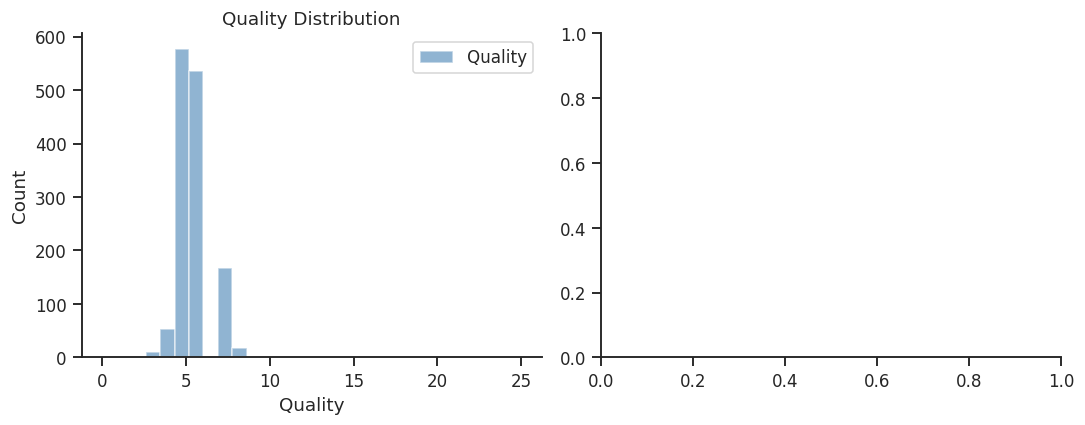

In [38]:
# TODO: look at the distribution of `quality`

fig, axes = plt.subplots(1, 2 , figsize=(10, 4))

# Histogram
bins = np.linspace(0, 25, 30)
axes[0].hist(df.quality, bins=bins, alpha=0.6, color='steelblue', label='Quality')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
axes[0].set_title('Quality Distribution')
axes[0].legend()


for ax in axes:
    sns.despine(ax=ax)



plt.tight_layout()
plt.show()

# (value_counts() and/or a histogram are both fine)

In [39]:
# TODO: separate predictors (X, the 11 physicochemical columns) from the
# response (y = quality), then standardise X ready for PCA.

y = df.quality
X = df.drop('quality', axis=1)
print(y)

#print(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('After scaling:')
print(f'  Mean per variable: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std  per variable: {X_scaled.std(axis=0).round(4)}')

# Hint: StandardScaler().fit_transform(X) -- do NOT standardise quality itself.

0       5
1       5
2       5
3       6
5       5
       ..
1593    6
1594    5
1595    6
1597    5
1598    6
Name: quality, Length: 1359, dtype: int64
After scaling:
  Mean per variable: [-0.  0.  0. -0.  0. -0.  0.  0. -0. -0.  0.]
  Std  per variable: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## Step 2 — PCA (0:30–1:30)

Fit PCA on the **standardised predictors only** — `quality` is the response
you are trying to predict, not a predictor, so it must not go into the PCA.

- [ ] Fit PCA, produce a scree plot (individual + cumulative variance)
- [ ] Decide how many components to keep, and by which criterion (→ **Checkpoint 2a**)
- [ ] Score plot (PC1 vs PC2), coloured by `quality` (→ **Checkpoint 2b**)
- [ ] Loading plot for the same two components (→ **Checkpoint 2c**)

In [42]:
# TODO: fit PCA on the standardised predictor matrix
pca = PCA()
scores = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('Explained variance per PC:')
for i, (ev, cum) in enumerate(zip(explained, cumulative), 1):
    bar = '█' * int(ev * 40)
    print(f'  PC{i}: {ev*100:5.1f}%  (cumulative: {cum*100:5.1f}%)  {bar}')

''' fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8, label='Individual')
ax.plot(range(1, len(explained)+1), cumulative*100, 'ro-', lw=2, ms=7, label='Cumulative')
ax.axhline(80, color='gray', ls=':', lw=1, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree Plot — Wine Data')
ax.legend()
ax.set_ylim(0, 110)
sns.despine(ax=ax)
plt.tight_layout()
plt.show() '''

Explained variance per PC:
  PC1:  28.3%  (cumulative:  28.3%)  ███████████
  PC2:  17.3%  (cumulative:  45.6%)  ██████
  PC3:  14.1%  (cumulative:  59.7%)  █████
  PC4:  11.4%  (cumulative:  71.1%)  ████
  PC5:   8.7%  (cumulative:  79.8%)  ███
  PC6:   5.8%  (cumulative:  85.6%)  ██
  PC7:   5.3%  (cumulative:  90.9%)  ██
  PC8:   3.7%  (cumulative:  94.7%)  █
  PC9:   3.1%  (cumulative:  97.8%)  █
  PC10:   1.6%  (cumulative:  99.5%)  
  PC11:   0.5%  (cumulative: 100.0%)  


" fig, ax = plt.subplots(figsize=(7, 4))\nax.bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8, label='Individual')\nax.plot(range(1, len(explained)+1), cumulative*100, 'ro-', lw=2, ms=7, label='Cumulative')\nax.axhline(80, color='gray', ls=':', lw=1, label='80% threshold')\nax.set_xlabel('Principal Component')\nax.set_ylabel('Explained variance (%)')\nax.set_title('Scree Plot — Wine Data')\nax.legend()\nax.set_ylim(0, 110)\nsns.despine(ax=ax)\nplt.tight_layout()\nplt.show() "

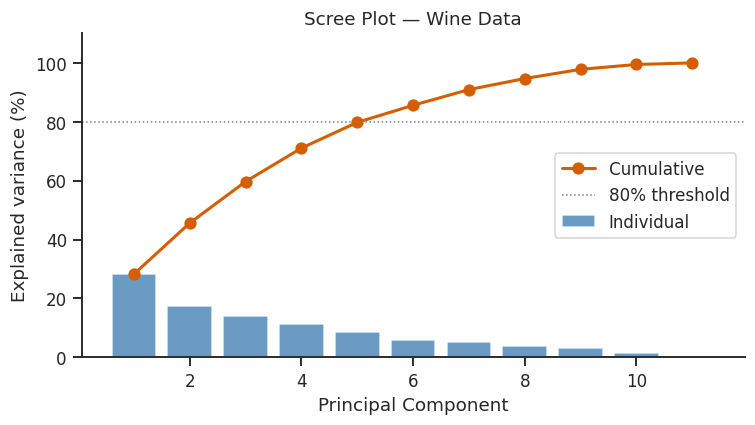

In [43]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8, label='Individual')
ax.plot(range(1, len(explained)+1), cumulative*100, 'ro-', lw=2, ms=7, label='Cumulative')
ax.axhline(80, color='gray', ls=':', lw=1, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree Plot — Wine Data')
ax.legend()
ax.set_ylim(0, 110)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

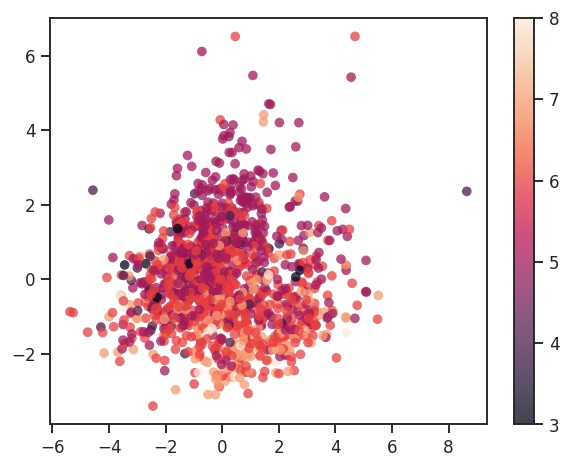

In [48]:
# TODO: score plot -- PC1 vs PC2, colour the points by `quality`
# (a continuous colourmap, e.g. cmap='viridis', works well for an ordinal 0-10 score)
qualities = df['quality'].values


fig, ax = plt.subplots()
s = ax.scatter(scores[:, 0], scores[:, 1], c=qualities
            , s=40, alpha=0.75, edgecolors='none')
fig.colorbar(s)



                       PC1   PC2
pH                   -0.44  0.00
volatile acidity     -0.24  0.28
alcohol              -0.12 -0.40
free sulfur dioxide  -0.02  0.51
total sulfur dioxide  0.04  0.58
residual sugar        0.13  0.24
chlorides             0.21  0.13
sulphates             0.25 -0.05
density               0.39  0.23
citric acid           0.46 -0.16
fixed acidity         0.49 -0.11


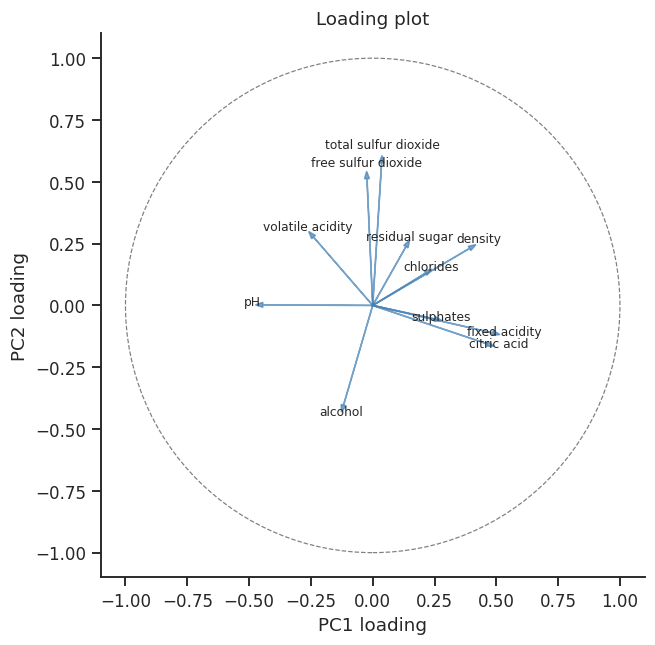

"\nfig, ax = plt.subplots(figsize=(8, 7))\n\n# Scores\nfor grade, color in colors_map.items():\n    mask = grades == grade\n    ax.scatter(scores[mask, 0], scores[mask, 1], c=color,\n               label=grade, s=30, alpha=0.6, edgecolors='none')\n\n# Loading arrows\nfor i, elem in enumerate(elements):\n    ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale),\n                xytext=(0, 0),\n                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))\n    ax.text(loadings[i, 0]*scale*1.12, loadings[i, 1]*scale*1.12,\n            elem, fontsize=10, fontweight='bold', ha='center')\n\nax.axhline(0, color='gray', lw=0.5)\nax.axvline(0, color='gray', lw=0.5)\nax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')\nax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')\nax.set_title('PCA Biplot — XRF Steel Data')\nax.legend(title='Grade', fontsize=9, loc='lower right')\nsns.despine(ax=ax)\nplt.tight_layout()\nplt.show()"

In [49]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?
# ── Biplot ────────────────────────────────────────────────────────────────────
scale = 3.0   # scale factor to make arrows visible


loadings_df = pd.DataFrame(pca.components_[:2].T, index=X.columns,
                            columns=['PC1', 'PC2'])
print(loadings_df.round(2).sort_values('PC1'))

fig, ax = plt.subplots(figsize=(7, 6))
for var in X.columns:
    x_co, y_co = loadings_df.loc[var, 'PC1'], loadings_df.loc[var, 'PC2']
    ax.arrow(0, 0, x_co, y_co, head_width=0.02, color='steelblue', alpha=0.7)
    ax.text(x_co*1.1, y_co*1.1, var, fontsize=8, ha='center')
circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', lw=0.8)
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1 loading'); ax.set_ylabel('PC2 loading')
ax.set_aspect('equal')
ax.set_title('Loading plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

'''
fig, ax = plt.subplots(figsize=(8, 7))

# Scores
for grade, color in colors_map.items():
    mask = grades == grade
    ax.scatter(scores[mask, 0], scores[mask, 1], c=color,
               label=grade, s=30, alpha=0.6, edgecolors='none')

# Loading arrows
for i, elem in enumerate(elements):
    ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings[i, 0]*scale*1.12, loadings[i, 1]*scale*1.12,
            elem, fontsize=10, fontweight='bold', ha='center')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA Biplot — XRF Steel Data')
ax.legend(title='Grade', fontsize=9, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()'''

---
## Step 3 — Model Quality: PLS *and* LDA (1:30–3:00)

Build **both** models today (see `instructions.md` for the full reasoning) —
not a choice between them. Keep both sections; do not delete either.

- [ ] Fit both models with a proper train/test split (or CV)
- [ ] Report validated performance for each, not training-set fit (→ **Checkpoints 3a, 3b**)
- [ ] Compare the two models (→ **Checkpoint 3c**)
- [ ] Identify which variable(s) matter most to each model (→ **Checkpoint 3d**)

### PLS (quality treated as continuous)

Optimal number of components: 5  (RMSECV = 0.66)


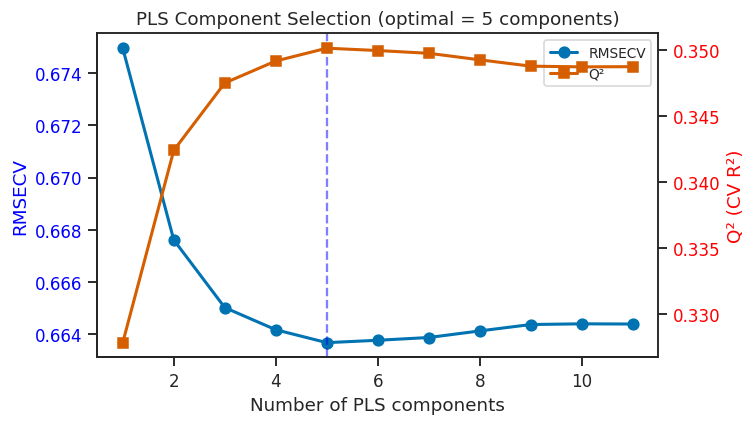

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score)

# TODO: train/test split (or set up cross-validation)
# Standardise X (Tg is already centred implicitly by PLS)
# Standardise X (Tg is already centred implicitly by PLS)
from sklearn.model_selection import cross_val_predict, KFold
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)


max_comp = X_scaled.shape[1] # Set max_comp to the number of features
rmsecv = []
q2     = []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for nc in range(1, max_comp + 1):
    pls_tmp = PLSRegression(n_components=nc, scale=False)
    qual_pred = cross_val_predict(pls_tmp, X_scaled, df.quality, cv=kf).ravel()
    rmsecv.append(np.sqrt(mean_squared_error(df.quality, qual_pred)))
    q2.append(r2_score(df.quality, qual_pred))

opt_nc = np.argmin(rmsecv) + 1
print(f'Optimal number of components: {opt_nc}  (RMSECV = {rmsecv[opt_nc-1]:.2f})')

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(range(1, max_comp+1), rmsecv, 'bo-', lw=2, ms=7, label='RMSECV')
ax1.axvline(opt_nc, color='blue', ls='--', alpha=0.5)
ax2.plot(range(1, max_comp+1), q2, 'rs-', lw=2, ms=7, label='Q²')
ax1.set_xlabel('Number of PLS components')
ax1.set_ylabel('RMSECV', color='blue')
ax2.set_ylabel('Q² (CV R²)', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax1.set_title(f'PLS Component Selection (optimal = {opt_nc} components)')
sns.despine(ax=ax1)
plt.tight_layout()
plt.show()

R²      (train) = 0.3542
Q²      (CV)    = 0.3305
RMSECV         = 0.68 °C


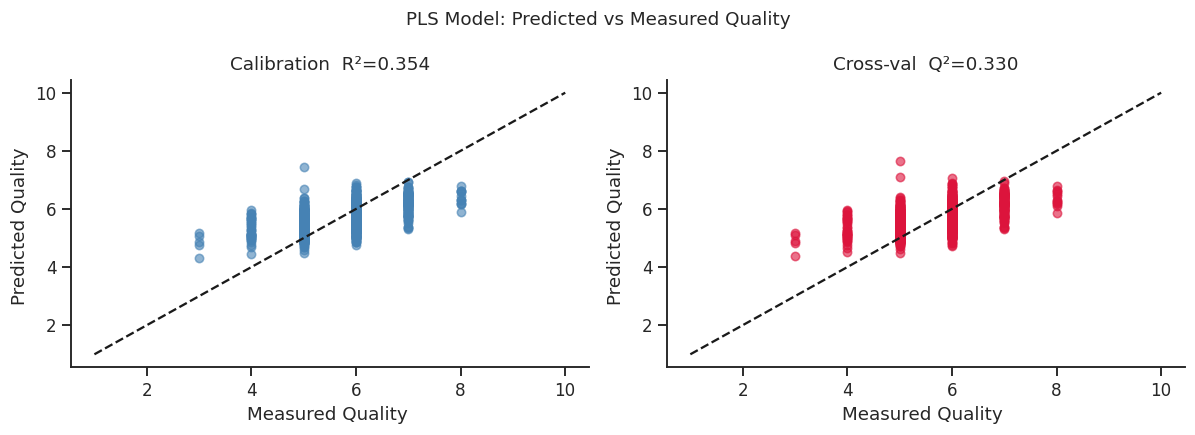

In [52]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


pls = PLSRegression(n_components=opt_nc, scale=False)
pls.fit(X_train_scaled, y_train)

qual_pred_train = pls.predict(X_train_scaled).ravel()
qual_pred_cv    = cross_val_predict(pls, X_train_scaled, y_train, cv=kf).ravel()

r2_train = r2_score(y_train, qual_pred_train)
r2_cv    = r2_score(y_train, qual_pred_cv)
rmse_cv  = np.sqrt(mean_squared_error(y_train, qual_pred_cv))

print(f'R²      (train) = {r2_train:.4f}')
print(f'Q²      (CV)    = {r2_cv:.4f}')
print(f'RMSECV         = {rmse_cv:.2f} °C')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (qual_p, label, color) in zip(
    axes,
    [(qual_pred_train, f'Calibration  R²={r2_train:.3f}', 'steelblue'),
     (qual_pred_cv,   f'Cross-val  Q²={r2_cv:.3f}',      'crimson')]
):
    ax.scatter(y_train, qual_p, s=30, alpha=0.6, color=color)
    lims = [min(y_train.min(), qual_p.min())-2, max(y_train.max(), qual_p.max())+2]
    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_xlabel('Measured Quality ')
    ax.set_ylabel('Predicted Quality ')
    ax.set_title(label)
    sns.despine(ax=ax)

plt.suptitle('PLS Model: Predicted vs Measured Quality', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: report test-set RMSE and/or R^2, and a predicted-vs-observed plot
# (include the y=x identity line for reference)


### LDA (quality binned into categories)

In [57]:
# TODO: define your quality bins explicitly here (e.g. low / medium / high).
# State your bin edges and reasoning on the answer sheet (Checkpoint 3b) --
# this is a real modelling decision, not a formality.
# Check the resulting class sizes: are they balanced?

trainlabels = []
#print(y.shape)
for q in y:
  if q in [3,4]:
    trainlabels.append('low')
  elif q in [5,6]:
    trainlabels.append('medium')
  elif q in [7,8]:
    trainlabels.append('high')
  else:
    print(q)

#print(trainlabels)



X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, trainlabels, test_size=0.25, random_state=42)

scaler_X2 = StandardScaler()
X_train_scaled2 = scaler_X2.fit_transform(X_train2)
X_test_scaled2 = scaler_X2.transform(X_test2)

#print(y_train2)

lda = LinearDiscriminantAnalysis()
lda_scores = lda.fit_transform(X_train2, y_train2)

# Explained variance ratio of each discriminant
print('Proportion of between-class variance explained:')
for i, ev in enumerate(lda.explained_variance_ratio_, 1):
    print(f'  LD{i}: {ev*100:.1f}%')

Proportion of between-class variance explained:
  LD1: 81.8%
  LD2: 18.2%


In [ ]:
# TODO: train/test split, then fit LinearDiscriminantAnalysis
#DID IN ABOVE CELL

Classification report (on TEST data):
              precision    recall  f1-score   support

         low       0.30      0.19      0.23        16
      medium       0.88      0.94      0.91       280
        high       0.67      0.50      0.57        44

    accuracy                           0.84       340
   macro avg       0.62      0.54      0.57       340
weighted avg       0.83      0.84      0.83       340



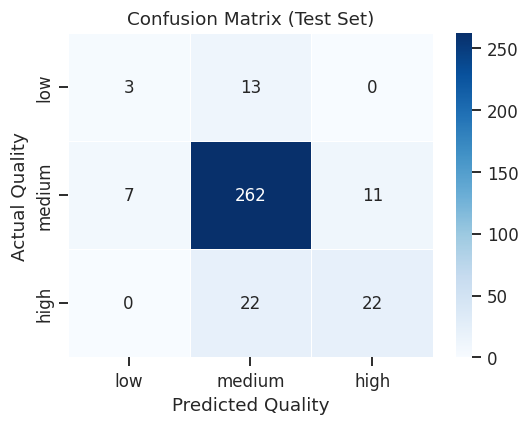

In [61]:
from sklearn.metrics import classification_report

y_pred = lda.predict(X_test2)

#print(y_pred)

#class_labels = np.sort(np.unique(np.concatenate((y_test2.unique(), y_pred))))
class_labels = ['low', 'medium', 'high']

print('Classification report (on TEST data):')
print(classification_report(y_test2, y_pred, labels=class_labels, target_names=[str(x) for x in class_labels]))

cm = confusion_matrix(y_test2, y_pred, labels=class_labels)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Quality')
ax.set_ylabel('Actual Quality')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

[[ 0.03220731 -0.18857839 -0.0162534   0.02437144 -0.1005546   0.05987475
  -0.1209158  -0.05278861 -0.09352855  0.1648339   0.27412354]]


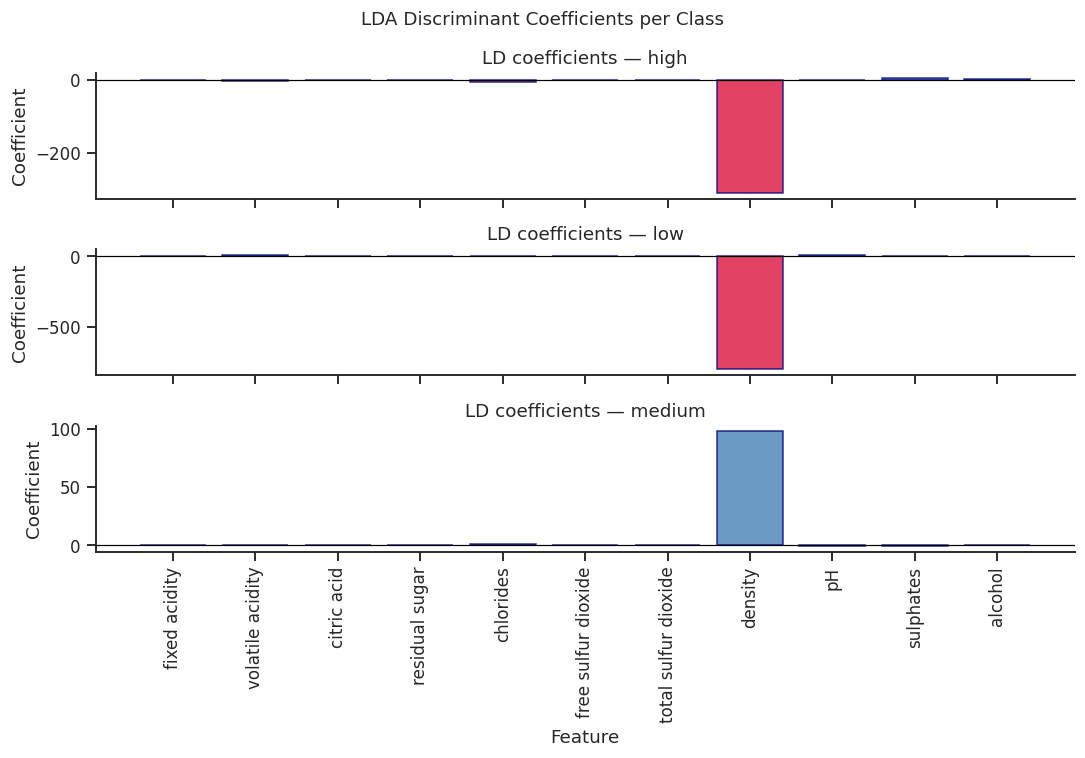

In [68]:
# TODO: Checkpoint 3c/3d groundwork -- pull out and compare the top
# variables from both models (PLS coefficients vs. LDA discriminant
# loadings). Your written comparison goes on the answer sheet.
#PLS TOP LOADING WAS TOTAL SULFUR DIOXIDE.
#LDA PREDICTED 5 BEST
plscoef = pls.coef_
print(plscoef)

coef_df = pd.DataFrame(lda.coef_, index=lda.classes_, columns=X.columns)

fig, axes = plt.subplots(len(lda.classes_), 1, figsize=(10, 7), sharex=True)
if len(lda.classes_) == 1: # Handle case with only one class
    axes = [axes]

for ax, grade in zip(axes.flat, lda.classes_):
    vals = coef_df.loc[grade]
    colors = ['steelblue' if v > 0 else 'crimson' for v in vals]
    ax.bar(X.columns, vals, color=colors, edgecolor='navy', alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'LD coefficients — {grade}')
    ax.set_ylabel('Coefficient')
    ax.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax)

axes[-1].set_xlabel('Feature')

plt.suptitle('LDA Discriminant Coefficients per Class', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 4 — Does It Transfer? White Wine (3:00–3:45)

Repeat the analysis on `winequality-white.csv` and check whether your
Step 2/3 findings are genuine wine chemistry or specific to the red-wine
dataset. You only need to redo **one** of PLS/LDA here, not both.

- [ ] Curate the white wine data the same way as Step 1 (its own duplicate/quality-distribution answer will differ from red)
- [ ] Redo the PCA from Step 2 on white wine (→ **Checkpoint 4a**)
- [ ] Redo ONE of your two Step 3 models on white wine (→ **Checkpoint 4b**)

Missing value counts per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Rows with any missing value:
Empty DataFrame
Columns: [fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, quality]
Index: []
Amount of rows duplicated:
937
Amount of rows duplicated:
0


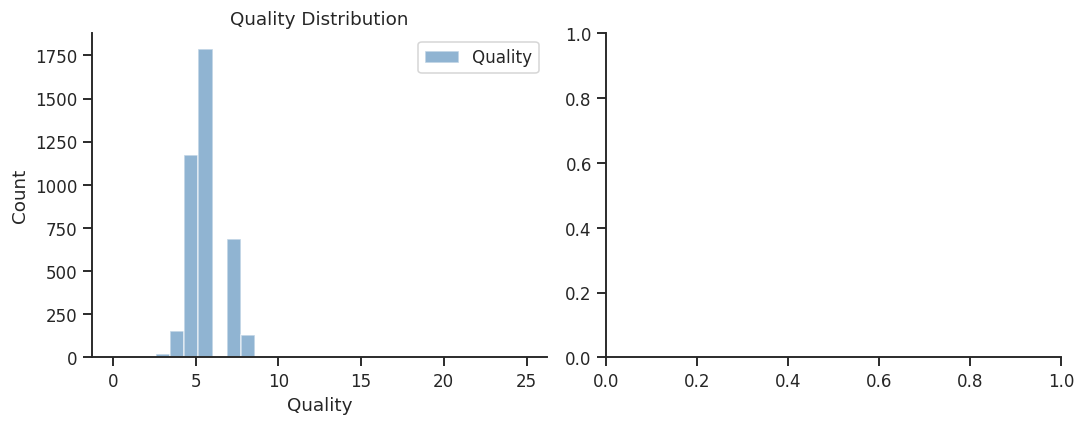

In [78]:
# TODO: load winequality-white.csv, curate it the same way as Step 1
# (missing values, duplicates, quality distribution)
df2 = pd.read_csv('winequality-white.csv', sep=';')
df2.head()

df2_missing = df2.copy()

print('Missing value counts per column:')
print(df2_missing.isnull().sum())

print('\nRows with any missing value:')
print(df2_missing[df2_missing.isnull().any(axis=1)])

print('Amount of rows duplicated:')
print(df2.duplicated().sum())

df2.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=False,)
print('Amount of rows duplicated:')
print(df2.duplicated().sum())

fig, axes = plt.subplots(1, 2 , figsize=(10, 4))

# Histogram
bins = np.linspace(0, 25, 30)
axes[0].hist(df2.quality, bins=bins, alpha=0.6, color='steelblue', label='Quality')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
axes[0].set_title('Quality Distribution')
axes[0].legend()

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()





In [79]:
# TODO: standardise the white-wine predictors and redo the PCA + scree/

y_white = df.quality
X_white = df.drop('quality', axis=1)
print(y_white)

#print(X)

scaler = StandardScaler()
X_scaled_white = scaler.fit_transform(X_white)

print('After scaling:')
print(f'  Mean per variable: {X_scaled_white.mean(axis=0).round(4)}')
print(f'  Std  per variable: {X_scaled_white.std(axis=0).round(4)}')


# score/loading plots from Step 2. Compare PC1's top-loading variables to
# what you found for red wine (Checkpoint 2c) -- write the comparison on
# the answer sheet (Checkpoint 4a).

0       5
1       5
2       5
3       6
5       5
       ..
1593    6
1594    5
1595    6
1597    5
1598    6
Name: quality, Length: 1359, dtype: int64
After scaling:
  Mean per variable: [-0.  0.  0. -0.  0. -0.  0.  0. -0. -0.  0.]
  Std  per variable: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# TODO: redo ONE of your two Step 3 models (PLS or LDA -- your choice) on
# white wine, same methodology as before. Compare validated performance and
# top variables to your red-wine result (Checkpoint 3a/3b/3d) -- write the
# comparison on the answer sheet (Checkpoint 4b).

---
## Wrap-up (3:45–4:00)

- [ ] Finalise your answer sheet (Checkpoints 1a–4b)

Hand in **this notebook** + your **answer sheet** — no separate report.